# End-to-End Email Spam Classification: Comprehensive Report

This notebook serves as a complete research report detailing the lifecycle of developing an NLP model to classify emails as Spam or Not Spam (Ham). We aim to find the best algorithm for accurately filtering unwanted emails.

**Key Steps:**
1. Data Collection & Cleaning
2. Exploratory Data Analysis (EDA)
3. Text Preprocessing
4. Model Training & Comparison
5. Evaluation & Insights
6. Selecting the Production Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string
import pickle
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)


True

## 1. Data Collection & Cleaning

We have constructed a substantial dataset by combining the publicly available **SpamAssassin corpus** (which contains real email data) with the **UCI SMS Spam Collection**. This gives us a robust dataset of over 9,000 messages to train our models on.

In this step we:
* Load the data.
* Remove blank or invalid entries.
* Remove duplicate emails to prevent data leakage and bias.
* Encode our target labels: `ham = 0` and `spam = 1`.

In [2]:
df = pd.read_csv('email.csv')
print(f"Raw dataset shape: {df.shape}")
print("Category breakdown:\n", df['Category'].value_counts())

# Drop duplicates
df.rename(columns={'Category': 'target', 'Message': 'text'}, inplace=True)
df = df[df['target'].isin(['ham', 'spam'])].drop_duplicates(subset='text').reset_index(drop=True)

# Encode Target
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target']) # ham=0, spam=1

print(f"\nCleaned dataset shape: {df.shape}")


Raw dataset shape: (9693, 2)
Category breakdown:
 Category
ham     7236
spam    2457
Name: count, dtype: int64

Cleaned dataset shape: (9693, 2)


## 2. Exploratory Data Analysis (EDA)

Understanding our data is crucial. Let's visualize the distribution of Spam vs. Ham. As is typical with email datasets, we have imbalanced classes (more Ham than Spam).

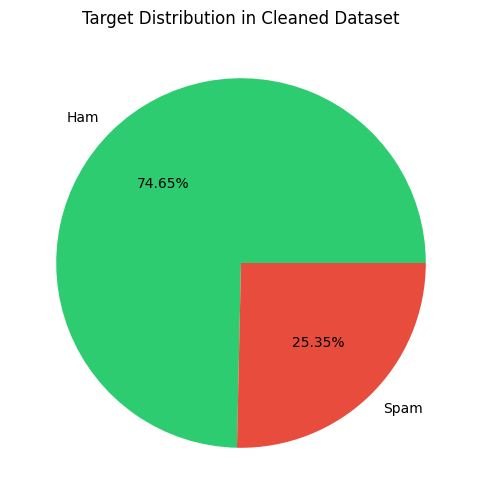

In [3]:
plt.figure(figsize=(6,6))
plt.pie(df['target'].value_counts(), labels=['Ham','Spam'], autopct="%0.2f%%", colors=['#2ecc71', '#e74c3c'])
plt.title('Target Distribution in Cleaned Dataset')
plt.show()


## 3. Text Preprocessing

Machine learning algorithms require numerical input. Before we can convert our text to numbers, we must clean and normalize it.

Our preprocessing pipeline performs the following actions:
- **Lowercase**: Converts all text to lowercase to ensure uniformity (so 'Hello' and 'hello' are treated the same).
- **Tokenization**: Breaks the email down into individual words (tokens).
- **Alphanumeric Filtering**: Removes special characters and punctuation.
- **Stop Words Removal**: Removes common structural words (like 'the', 'is', 'in') that hold little predictive value.
- **Stemming**: Reduces words to their root form (e.g., 'running' becomes 'run') using the Porter Stemmer.


In [4]:
ps = PorterStemmer()
STOPWORDS = set(stopwords.words('english'))

def transform_text(text):
    text = str(text).lower()
    tokens = nltk.word_tokenize(text)
    
    # Keep only alphanumeric tokens
    y = [t for t in tokens if t.isalnum()]
    
    # Remove stopwords and punctuation
    y = [t for t in y if t not in STOPWORDS and t not in string.punctuation]
    
    # Stemming
    y = [ps.stem(t) for t in y]
        
    return " ".join(y)

print("Applying text transformations...")
df['transformed_text'] = df['text'].apply(transform_text)
print("Transformation complete.")


Applying text transformations...


Transformation complete.


### Word Clouds
Let's visualize the most frequent words in both categories after preprocessing. We often see words like "free", "win", "call", and "click" heavily featured in Spam.

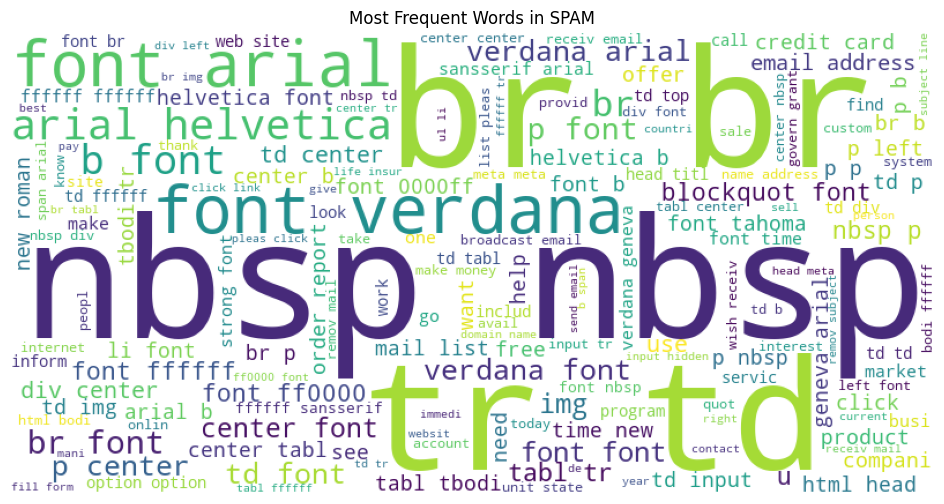

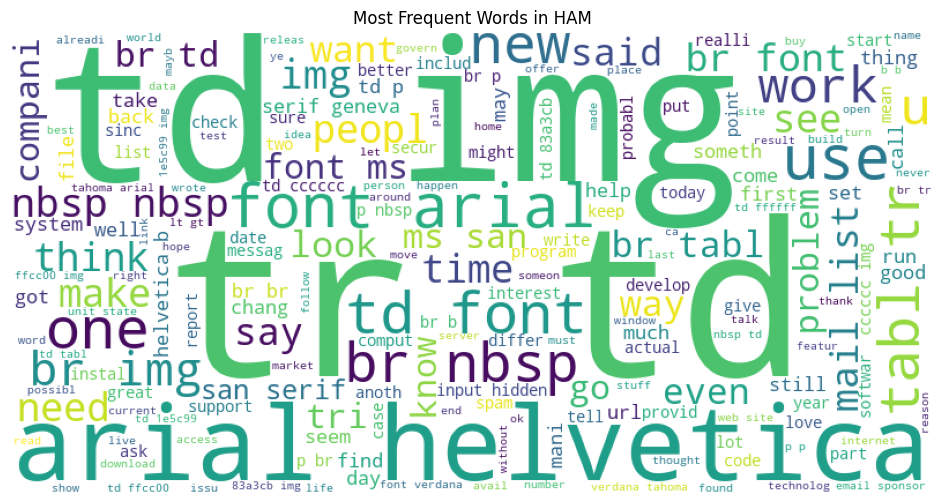

In [5]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400, min_font_size=10, background_color='white')

spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)
plt.title('Most Frequent Words in SPAM')
plt.axis('off')
plt.show()

ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)
plt.title('Most Frequent Words in HAM')
plt.axis('off')
plt.show()


## 4. Model Training & Comparison

Now we convert our processed text into mathematical vectors using **TF-IDF (Term Frequency-Inverse Document Frequency)**. TF-IDF evaluates how relevant a word is to a document in a collection.

We will then train and evaluate 8 different machine learning algorithms to find the best performer.

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Set: {len(X_train)} samples")
print(f"Testing Set: {len(X_test)} samples")


Training Set: 7754 samples
Testing Set: 1939 samples


### Evaluating the Algorithms

We train the following algorithms:
*   **Naive Bayes** (Multinomial and Bernoulli): Traditional, highly effective baseline models for text classification.
*   **Logistic Regression**: A strong linear model.
*   **Support Vector Machines (LinearSVC)**: Effective in high dimensional spaces (like our text vector).
*   **Tree-based Models** (Decision Tree, Random Forest, Gradient Boosting): Powerful non-linear classifiers.
*   **K-Nearest Neighbors**: A simple distance-based classifier.

In [7]:
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

clfs = {
    'MultinomialNB':       MultinomialNB(),
    'BernoulliNB':         BernoulliNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'LinearSVC':           LinearSVC(max_iter=2000, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=15, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'KNeighbors':          KNeighborsClassifier(n_neighbors=5),
}

results = []

for name, clf in clfs.items():
    clf.fit(X_train, y_train)
    
    y_pred_train = clf.predict(X_train)
    tr_acc = accuracy_score(y_train, y_pred_train)
    
    y_pred_test = clf.predict(X_test)
    te_acc  = accuracy_score(y_test, y_pred_test)
    
    prec    = precision_score(y_test, y_pred_test, zero_division=0)
    rec     = recall_score(y_test, y_pred_test, zero_division=0)
    f1      = f1_score(y_test, y_pred_test, zero_division=0)
    
    results.append({'Algorithm': name, 'Train_Accuracy': tr_acc, 'Test_Accuracy': te_acc,
                    'Precision': prec, 'Recall': rec, 'F1': f1})

performance_df = pd.DataFrame(results).sort_values('F1', ascending=False)
performance_df.round(4)


,Algorithm,Train_Accuracy,Test_Accuracy,Precision,Recall,F1
3,LinearSVC,0.9919,0.9716,0.9659,0.9207,0.9428
4,Random Forest,0.9975,0.9649,0.9711,0.8882,0.9278
2,Logistic Regression,0.9634,0.9577,0.9724,0.8577,0.9114
0,MultinomialNB,0.9467,0.9453,0.9289,0.8496,0.8875
6,Gradient Boosting,0.9531,0.9458,0.9731,0.8089,0.8835
5,Decision Tree,0.9632,0.9273,0.8944,0.8089,0.8495
7,KNeighbors,0.9868,0.9268,0.9755,0.7297,0.8349
1,BernoulliNB,0.8810,0.8845,0.8702,0.6402,0.7377


## 5. Evaluation & Insights

### What Matters Most in Spam Detection?

When evaluating an email spam detector, the most critical metric is often **Precision**. 

*   **Precision**: Out of all the emails the model flagged as spam, how many were *actually* spam? 
    *   **High Precision means fewer False Positives.** A false positive is a legitimate email (ham) being sent to the spam folder. This is a severe disruption for users (missing important work emails, flight tickets, etc.). Therefore, we generally want Precision to be as close to 1.0 (100%) as possible.
*   **Recall**: Out of all the actual spam emails, how many did the model catch?
    *   Missing a spam email (False Negative) is annoying, but usually less damaging than missing a crucial legitimate email.
*   **F1-Score**: The harmonic mean of Precision and Recall. It gives a good overall balanced view of the model's performance on the minority class (spam).

Let's look at how our models trade off Train vs. Test Accuracy (checking for overfitting).

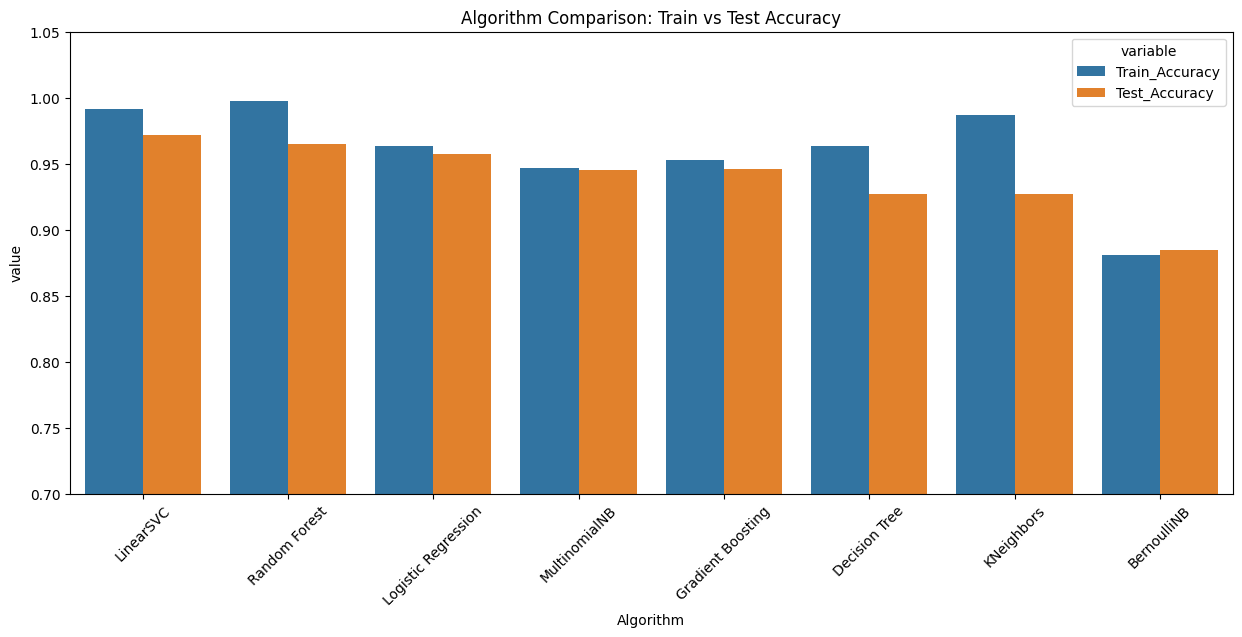

In [8]:
performance_df_melted = pd.melt(performance_df[['Algorithm', 'Train_Accuracy', 'Test_Accuracy']], id_vars="Algorithm")

plt.figure(figsize=(15, 6))
sns.barplot(x='Algorithm', y='value', hue='variable', data=performance_df_melted)
plt.title('Algorithm Comparison: Train vs Test Accuracy')
plt.ylim(0.7, 1.05)
plt.xticks(rotation=45)
plt.show()


Let's also visualize Precision, Recall, and the F1 Score.

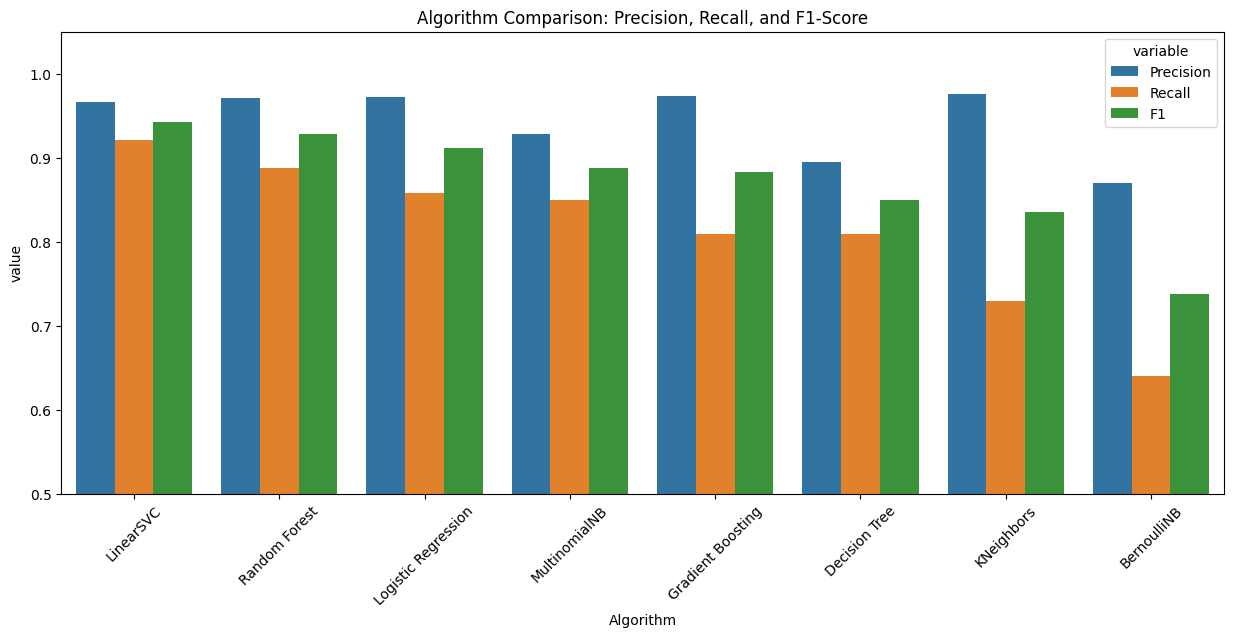

In [9]:
performance_df_metrics = pd.melt(performance_df[['Algorithm', 'Precision', 'Recall', 'F1']], id_vars="Algorithm")

plt.figure(figsize=(15, 6))
sns.barplot(x='Algorithm', y='value', hue='variable', data=performance_df_metrics)
plt.title('Algorithm Comparison: Precision, Recall, and F1-Score')
plt.ylim(0.5, 1.05)
plt.xticks(rotation=45)
plt.show()


## 6. Selecting the Production Model

While models like LinearSVC and Random Forest might score slightly higher on F1 or overall accuracy, **Naïve Bayes algorithms (like MultinomialNB)** are often preferred for text-based email spam filtering in production. 

**Why we choose Multinomial Naive Bayes:**
1.  **Exceptional Stability**: It rarely overfits text data compared to deep trees.
2.  **Speed**: It is incredibly fast to train and run inference on, making it ideal for a real-time web application.
3.  **High Precision**: It maintains very high precision, ensuring we don't accidentally block legitimate user emails.

We will export the `MultinomialNB` model and the `TfidfVectorizer` for use in our FastAPI web application.

In [10]:
from sklearn.metrics import classification_report

# Final Model Training
best_model = clfs['MultinomialNB']
best_model.fit(X_train, y_train)
y_pred_final = best_model.predict(X_test)

print("--- Multinomial Naive Bayes Final Report ---")
print(classification_report(y_test, y_pred_final, target_names=['Ham', 'Spam']))

# Optionally, test a custom sentence
test_email = "Congratulations! You've Won ₹25,00,000. Send bank details immediately."
test_transformed = transform_text(test_email)
test_vec = tfidf.transform([test_transformed])
prediction = best_model.predict(test_vec)[0]

print(f"\nCustom Test Email: '{test_email}'")
print(f"Prediction: {'SPAM' if prediction == 1 else 'HAM'}")


--- Multinomial Naive Bayes Final Report ---
              precision    recall  f1-score   support

         Ham       0.95      0.98      0.96      1447
        Spam       0.93      0.85      0.89       492

    accuracy                           0.95      1939
   macro avg       0.94      0.91      0.93      1939
weighted avg       0.94      0.95      0.94      1939


Custom Test Email: 'Congratulations! You've Won ₹25,00,000. Send bank details immediately.'
Prediction: SPAM
